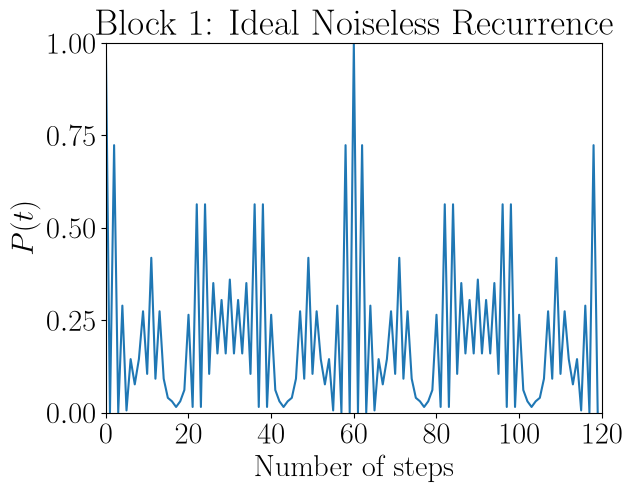

In [1]:
"""
Quantum Walk Simulations
========================
Numerical simulations supporting the paper:

    Quantum direct communication protocol using recurrence in k-cycle quantum walks
    Panda, Yasir, Chandrashekar — Physical Review A 107, 022611 (2023)
    DOI: https://doi.org/10.1103/PhysRevA.107.022611

This script contains three independent simulation blocks:

    Block 1 — Ideal 5-cycle DTQW (noiseless)
    Block 2 — 5-cycle DTQW with amplitude damping noise
    Block 3 — 5-cycle DTQW with depolarizing noise

Each block is self-contained and can be run in isolation.
LaTeX rendering is used for axis labels where noted; comment out
the two plt.rc(...) lines in each block if LaTeX is not installed.
"""

# ─────────────────────────────────────────────────────────────────────────────
# Common dependencies
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import qutip

# Safe LaTeX toggle (falls back to standard text if LaTeX is not available)
try:
    plt.rc('text', usetex=True)
    plt.rc('font', family='serif')
    lbl_steps, lbl_p, lbl_t, lbl_mi = r'Number of steps', r'$P(t)$', r'$t$', r'$I_{\rm mu}(t)$'
except Exception:
    lbl_steps, lbl_p, lbl_t, lbl_mi = 'Number of steps', 'P(t)', 't', 'I_mu(t)'

plt.rcParams.update({'font.size': 22})

# Shared Spatial Configuration
P = 5          # number of positions (nodes on the cycle)
n_steps_ideal = 120  # Block 1 runs up to 120 steps to show two 60-step periods
n_steps_noisy = 61   # Blocks 2 & 3 run up to 61 steps

# --- Coin basis states ---
coin0 = qutip.basis(2, 0)
coin1 = qutip.basis(2, 1)
C00   = coin0 * coin0.dag()  # |0⟩⟨0|
C01   = coin0 * coin1.dag()  # |0⟩⟨1|
C10   = coin1 * coin0.dag()  # |1⟩⟨0|
C11   = coin1 * coin1.dag()  # |1⟩⟨1|

# --- Initial state: walker at node 0, coin = (|0⟩ + i|1⟩)/√2 ---
posn0_vec = np.zeros(P)
posn0_vec[0] = 1
posn0_qobj = qutip.Qobj(posn0_vec)
psi0 = qutip.tensor(posn0_qobj, qutip.Qobj(coin0 + coin1 * 1j) / np.sqrt(2.0))

# --- Shift operator and walk unitary ---
ShiftPlus  = qutip.Qobj(np.roll(np.eye(P),  1, axis=0))
ShiftMinus = qutip.Qobj(np.roll(np.eye(P), -1, axis=0))
S_hat = qutip.tensor(ShiftPlus, C00) + qutip.tensor(ShiftMinus, C11)

# --- 5-cycle / 10-cycle coin operator ---
rho_param = (5 - np.sqrt(5)) / 10
C_hat = (np.sqrt(rho_param)     * C00
         + np.sqrt(1 - rho_param) * C01
         + np.sqrt(1 - rho_param) * C10
         - np.sqrt(rho_param)     * C11)

U = S_hat * qutip.tensor(qutip.Qobj(np.eye(P)), qutip.Qobj(C_hat))

# ═════════════════════════════════════════════════════════════════════════════
# BLOCK 1 — Ideal 5-Cycle Discrete-Time Quantum Walk (Noiseless)
# ═════════════════════════════════════════════════════════════════════════════
#
# Simulates an ideal (noiseless) DTQW on a 5-node cycle graph.
# The walker starts at node 0 with coin state (|0⟩ + i|1⟩)/√2.
# The return probability P(t) at node 0 is plotted over n_steps steps.
#
# Coin operator for the k-cycle walk:
#   C_hat = [[√ρ,  √(1−ρ)],
#            [√(1−ρ), −√ρ]]   with ρ = (5 − √5) / 10  (5-cycle)
#
# The full walk unitary is  U = S · (I_P ⊗ C_hat),
# where S = ShiftPlus ⊗ |0⟩⟨0| + ShiftMinus ⊗ |1⟩⟨1|.
# ─────────────────────────────────────────────────────────────────────────────

# Track return probability at node 0 using high-efficiency vector slicing
prob_b1 = np.zeros(n_steps_ideal)
psi_b1 = psi0.copy()

for n in range(n_steps_ideal):
    # Slice the first two entries belonging to node 0 directly out of the raw vector array
    node0_amplitudes = psi_b1.full()[0:2]
    prob_b1[n] = np.sum(np.abs(node0_amplitudes)**2)
    
    # Step forward via fast state vector multiplication
    psi_b1 = U * psi_b1

# --- Plot: return probability at node 0 ---
plt.figure()
ax = plt.gca()
ax.set_yticks(np.arange(0, 1.01, 0.25))
ax.set_xticks(np.arange(0, n_steps_ideal + 1, 20))
ax.plot(range(n_steps_ideal), prob_b1)
plt.xlabel(lbl_steps)
plt.ylabel(lbl_p)
plt.xlim([0, n_steps_ideal])
plt.ylim([0, 1])
plt.title('Block 1: Ideal Noiseless Recurrence')
# plt.savefig("return_prob_5cycle.pdf", format="pdf", bbox_inches="tight")
plt.show()


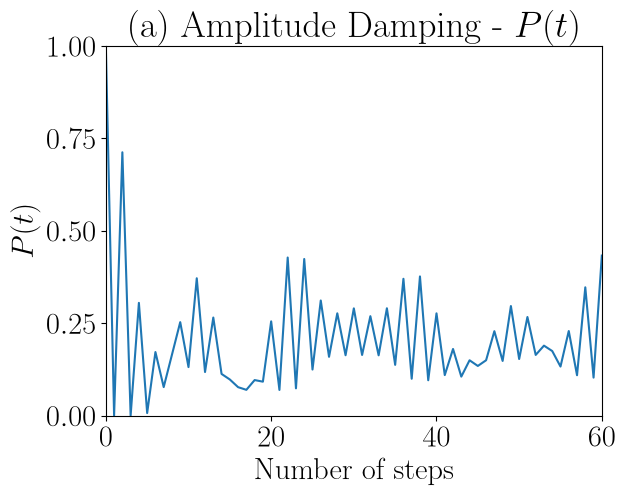

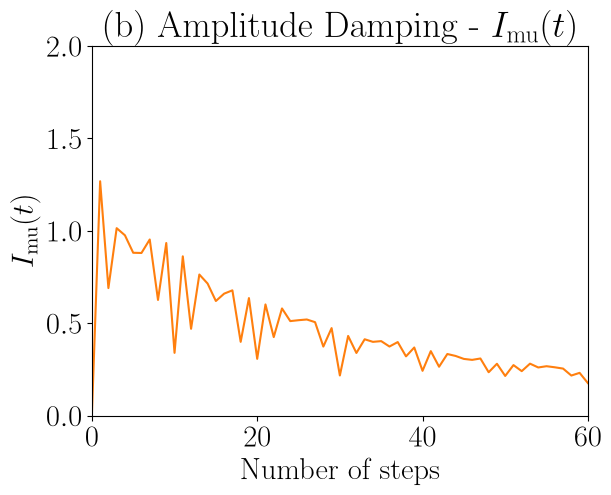

In [2]:
# ═════════════════════════════════════════════════════════════════════════════
# BLOCK 2 — 10-Cycle DTQW with Amplitude Damping Noise
# ═════════════════════════════════════════════════════════════════════════════
#
# Simulates a DTQW on a 5-node ring using the 10-cycle coin operator,
# with an amplitude damping channel applied to the coin qubit at every step.
#
# Amplitude damping Kraus operators (damping parameter p):
#   E_0 = [[1, 0      ],    E_1 = [[0, √p],
#          [0, √(1−p)]]            [0,  0]]
#
# The mixed state is propagated as:
#   ρ_n = E_0 ρ E_0† + E_1 ρ E_1†
# and the state is re-normalised after each step.
#
# Outputs: return probability P(t) and coin-position mutual information I(ρ).
# ─────────────────────────────────────────────────────────────────────────────

p = 0.05  # amplitude damping parameter

# --- Amplitude damping Kraus operators (act on coin subspace) ---
E_0 = qutip.tensor(qutip.qeye(P), qutip.Qobj([[1, 0], [0, np.sqrt(1 - p)]]))
E_1 = qutip.tensor(qutip.qeye(P), qutip.Qobj([[0, np.sqrt(p)], [0, 0]]))

prob_b2 = np.zeros(n_steps_noisy)
entropy_b2 = np.zeros(n_steps_noisy)

# Evaluate initial density state properties at t = 0
rho_b2 = psi0 * psi0.dag()
prob_b2[0] = qutip.ptrace(rho_b2, 0).full()[0, 0].real
entropy_b2[0] = qutip.entropy_mutual(rho_b2, 0, 1)

for n in range(1, n_steps_noisy):
    rho_evolved = U * rho_b2 * U.dag()
    
    # Apply amplitude damping channel map
    rho_b2 = E_0 * rho_evolved * E_0.dag() + E_1 * rho_evolved * E_1.dag()
    rho_b2 = rho_b2.unit()  # Re-normalise
    
    # Compute metrics
    rho_reduced = qutip.ptrace(rho_b2, 0)
    prob_b2[n] = rho_reduced.full()[0, 0].real
    entropy_b2[n] = qutip.entropy_mutual(rho_b2, 0, 1)

# --- Plot 1: return probability P(t) ---
plt.figure()
ax = plt.gca()
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
ax.plot(range(n_steps_noisy), prob_b2)
plt.xlabel(lbl_steps)
plt.ylabel(lbl_p)
plt.title(r'(a) Amplitude Damping - $P(t)$')
plt.xlim([0, n_steps_noisy - 1])
plt.ylim([0.0, 1.0])
# plt.savefig("AmpliDamp_prob.pdf", format="pdf", bbox_inches="tight")
plt.show()

# --- Plot 2: coin-position mutual information I_mu(t) ---
plt.figure()
ax = plt.gca()
ax.set_yticks([0, 0.5, 1, 1.5, 2])
ax.plot(range(n_steps_noisy), entropy_b2, color='tab:orange')
plt.xlabel(lbl_steps)
plt.ylabel(lbl_mi)
plt.title(r'(b) Amplitude Damping - $I_{\rm mu}(t)$')
plt.xlim([0, n_steps_noisy - 1])
plt.ylim([0.0, 2.0])
# plt.savefig("AmpliDamp_mut_inf.pdf", format="pdf", bbox_inches="tight")
plt.show()


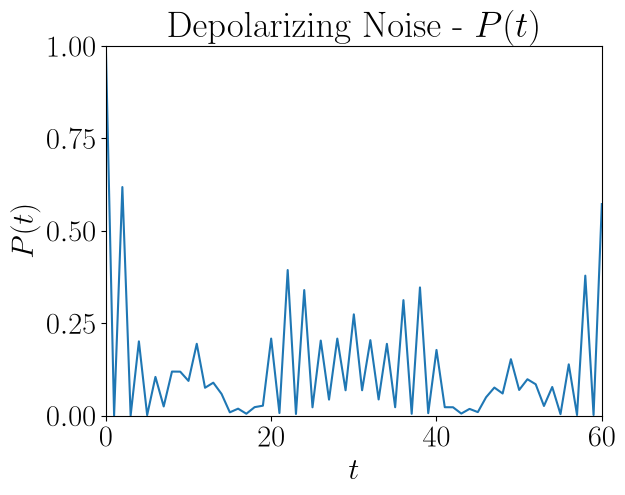

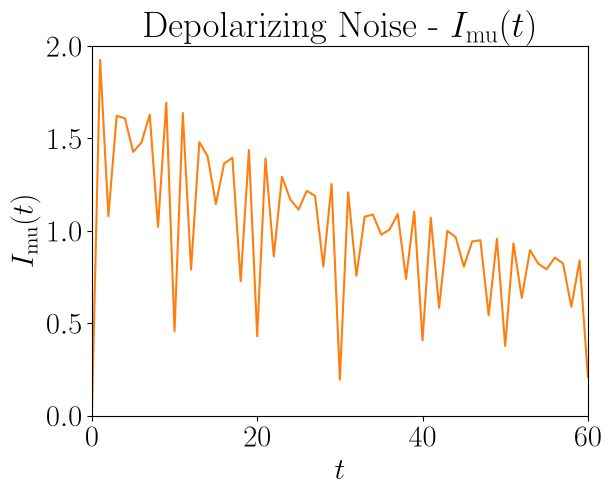

In [3]:
# ═════════════════════════════════════════════════════════════════════════════
# BLOCK 3 — 5-Cycle DTQW with Depolarizing Noise
# ═════════════════════════════════════════════════════════════════════════════
#
# Simulates a DTQW on a 5-node cycle with a depolarizing channel applied
# to the coin qubit at every step.
#
# Depolarizing Kraus operators (noise parameter δ = de):
#   E_0 = √(1 − 3δ/4) · I
#   E_1 = √(δ/4) · X
#   E_2 = √(δ/4) · Y
#   E_3 = √(δ/4) · Z
#
# The mixed density matrix is propagated as:
#   ρ_{n+1} = U ρ_n U† → Σ_k E_k ρ_{n+1} E_k†
#
# Outputs: return probability P(t) and coin-position mutual information I_μ(t).
# ─────────────────────────────────────────────────────────────────────────────

de = 0.01  # depolarizing noise parameter

# --- Depolarizing Kraus operators (proportional to Pauli matrices {I, X, Y, Z}) ---
D_0 = qutip.tensor(qutip.qeye(P), qutip.Qobj([[np.sqrt(1 - 3 * de / 4), 0], [0, np.sqrt(1 - 3 * de / 4)]]))
D_1 = qutip.tensor(qutip.qeye(P), qutip.Qobj([[0, np.sqrt(de / 4)], [np.sqrt(de / 4), 0]]))
D_2 = qutip.tensor(qutip.qeye(P), qutip.Qobj([[0, -1j * np.sqrt(de / 4)], [1j * np.sqrt(de / 4), 0]]))
D_3 = qutip.tensor(qutip.qeye(P), qutip.Qobj([[np.sqrt(de / 4), 0], [0, -np.sqrt(de / 4)]]))

prob_b3 = np.zeros(n_steps_noisy)
Imu_b3  = np.zeros(n_steps_noisy)

rho_b3  = psi0 * psi0.dag()
rho1r = qutip.ptrace(rho_b3, 0)
prob_b3[0] = (rho1r * rho1r.dag()).full()[0, 0].real
Imu_b3[0] = qutip.entropy_mutual(rho_b3, 0, 1, base=2)

for ii in range(1, n_steps_noisy):
    rho2 = U * rho_b3 * U.dag()
    rho_b3 = (D_0 * rho2 * D_0.dag()
            + D_1 * rho2 * D_1.dag()
            + D_2 * rho2 * D_2.dag()
            + D_3 * rho2 * D_3.dag())

    rho3r    = qutip.ptrace(rho_b3, 0)
    prob_b3[ii] = (rho3r * rho3r.dag()).full()[0, 0].real
    Imu_b3[ii]  = qutip.entropy_mutual(rho_b3, 0, 1, base=2)

# --- Plots: P(t) and I_mu(t) as separate figures ---
# Figure 1: return probability P(t)
plt.figure()
ax = plt.gca()
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
ax.plot(range(n_steps_noisy), prob_b3)
plt.xlabel(lbl_t)
plt.ylabel(lbl_p)
plt.title(r'Depolarizing Noise - $P(t)$')
plt.xlim([0, n_steps_noisy - 1])
plt.ylim([0.0, 1.0])
# plt.savefig("DepolNoise_prob.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Figure 2: coin-position mutual information I_mu(t)
plt.figure()
ax = plt.gca()
ax.set_yticks([0, 0.5, 1, 1.5, 2])
ax.plot(range(n_steps_noisy), Imu_b3, color='tab:orange')
plt.xlabel(lbl_t)
plt.ylabel(lbl_mi)
plt.title(r'Depolarizing Noise - $I_{\rm mu}(t)$')
plt.xlim([0, n_steps_noisy - 1])
plt.ylim([0.0, 2.0])
# plt.savefig("DepolNoise_mut_inf.pdf", format="pdf", bbox_inches="tight")
plt.show()